# Pertemuan 9 - Klasifikasi Breast Cancer

Praktikum ini bertujuan membandingkan performa dua algoritma machine learning, yaitu Logistic Regression dan Decision Tree dalam melakukan klasifikasi kanker payudara menggunakan dataset Breast Cancer Wisconsin dari Scikit-Learn.

Tahapan yang dilakukan meliputi:

- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Pelatihan Logistic Regression
- Pelatihan Decision Tree
- Evaluasi dan Perbandingan Model

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape Data :", X.shape)

print("\nDistribusi Target")
print(pd.Series(y).value_counts())

print("\nDistribusi Target (%)")
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape Data : (569, 30)

Distribusi Target
1    357
0    212
Name: count, dtype: int64

Distribusi Target (%)
1    0.627
0    0.373
Name: proportion, dtype: float64


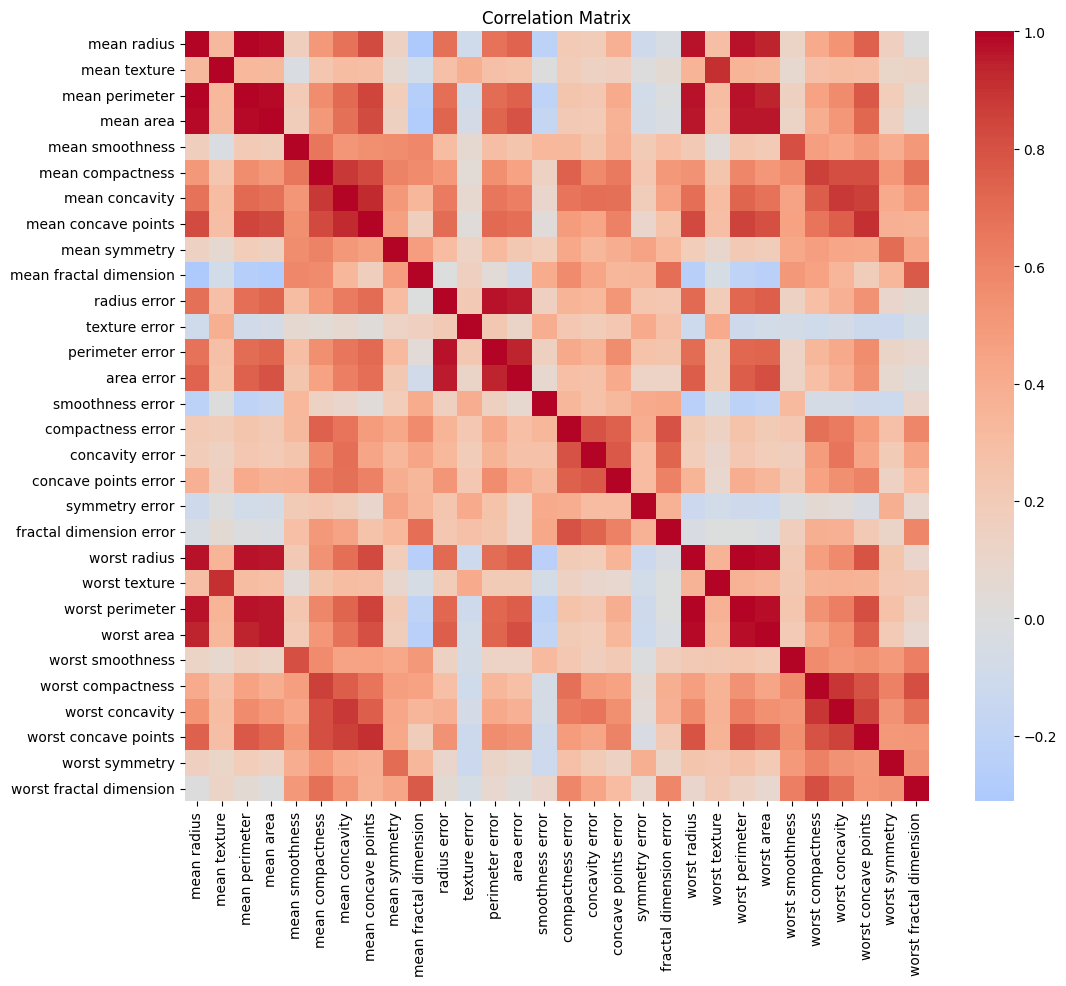

In [2]:
plt.figure(figsize=(12,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Hasil EDA

Dataset terdiri dari 569 data pasien dengan 30 fitur numerik.

Target terdiri dari:

- 0 = Malignant (Kanker)
- 1 = Benign (Tidak Kanker)

Visualisasi korelasi menunjukkan beberapa fitur memiliki hubungan yang cukup tinggi sehingga berpotensi memberikan informasi penting dalam proses klasifikasi.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Preprocessing

Data dibagi menjadi:

- Training : 80%
- Testing : 20%

StandardScaler digunakan karena Logistic Regression sensitif terhadap skala data.

In [4]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df = coef_df.reindex(
    coef_df.Coefficient.abs().sort_values(ascending=False).index
)

coef_df.head(10)

,Feature,Coefficient
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


## Interpretasi Logistic Regression

Koefisien terbesar menunjukkan fitur yang paling berpengaruh terhadap prediksi kanker.

Semakin besar nilai absolut koefisien, semakin besar pengaruh fitur tersebut terhadap keputusan model.

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

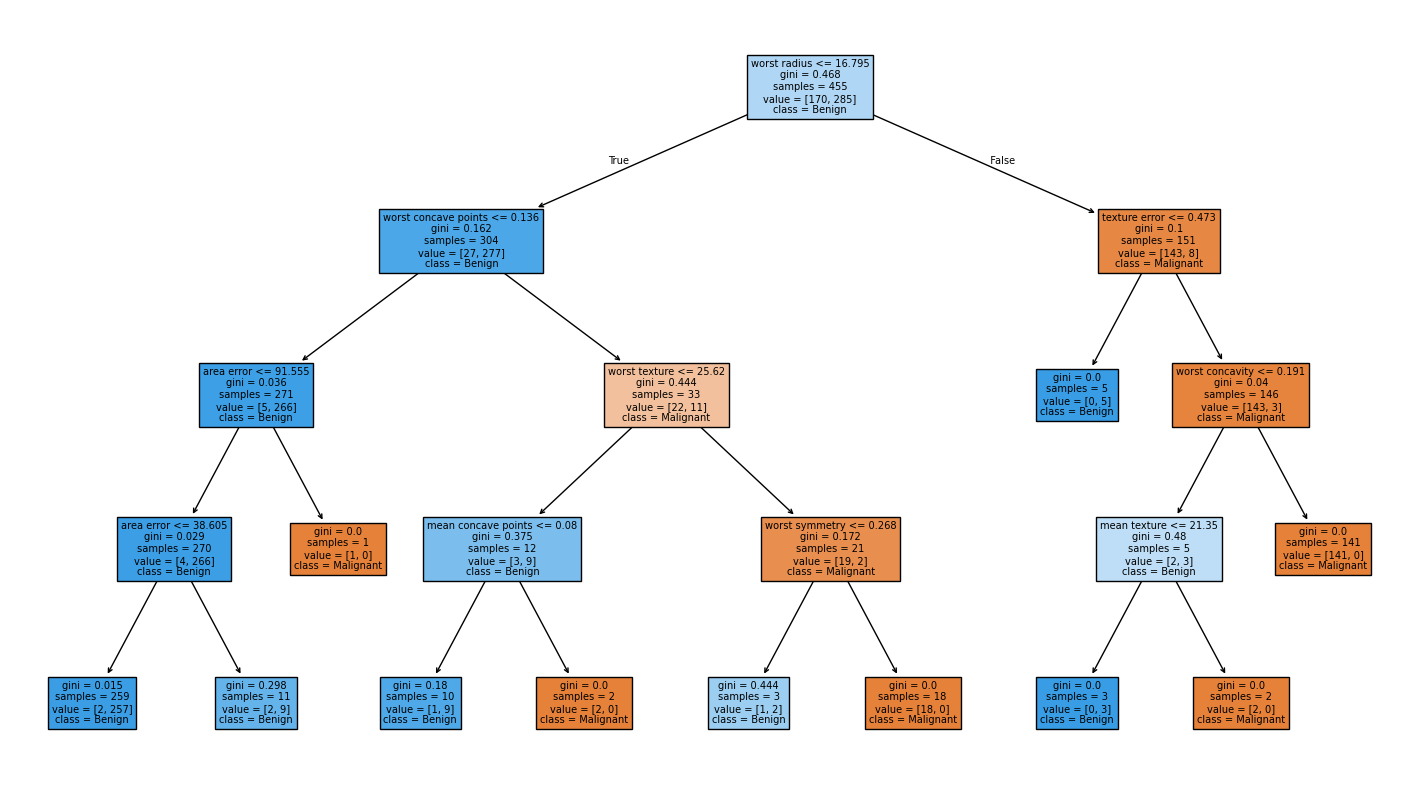

In [6]:
plt.figure(figsize=(18,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant","Benign"],
    filled=True
)

plt.show()

In [7]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree
}

for name, pred in models.items():

    print("="*50)
    print(name)
    print("="*50)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, pred))

    print("Accuracy :", round(accuracy_score(y_test, pred),3))
    print("Precision:", round(precision_score(y_test, pred),3))
    print("Recall   :", round(recall_score(y_test, pred),3))
    print("F1 Score :", round(f1_score(y_test, pred),3))

Logistic Regression

Confusion Matrix
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1 Score : 0.986
Decision Tree

Confusion Matrix
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1 Score : 0.951


# Kesimpulan

Pada praktikum ini dilakukan perbandingan antara Logistic Regression dan Decision Tree dalam melakukan klasifikasi kanker payudara.

Beberapa hal yang dapat disimpulkan:

- Logistic Regression umumnya memberikan performa yang lebih stabil karena menggunakan seluruh informasi fitur secara linear.
- Decision Tree lebih mudah diinterpretasikan karena menghasilkan aturan keputusan berbentuk pohon, namun lebih rentan mengalami overfitting.
- Recall merupakan metrik yang paling penting pada kasus diagnosis kanker karena menunjukkan kemampuan model menemukan seluruh pasien yang benar-benar mengidap kanker.
- False Negative sangat berbahaya karena pasien yang sebenarnya terkena kanker dapat diprediksi sehat sehingga terlambat mendapatkan penanganan medis.
- Oleh karena itu, model dengan Recall yang lebih tinggi lebih disarankan dibanding hanya melihat Accuracy yang tinggi.

Secara keseluruhan, kedua model memiliki performa yang baik, namun pemilihan model terbaik sebaiknya mempertimbangkan nilai Recall selain Accuracy.